In [1]:
import numpy as np
import pandas as pd
import pickle, os
from astropy.time import Time
import matplotlib.pyplot as plt
import seaborn as sns
import dynesty
import emcee
from dynesty import plotting as dyplot
from bbh_agn_lightcurve import BBHAGNLightcurve

/Users/simran/anaconda3/lib/python3.11/site-packages/seaborn/_statistics.py:31: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.stats import gaussian_kde


In [2]:
#Setup for events and lc grid
events = {
    "S250328ae": {
        "chirp_mass": 11.96 + 9.0 - 5.84,
        "total_mass" : 28.93 + 22.4 - 14.23,
        "dL": 511,
        "start": '2025-03-28 05:40:27.419',
    }
}
L = BBHAGNLightcurve(events, "S250328ae", filter_file="data/decam_transmission_curves.txt")

In [3]:
# Graham model parameters
vk_array = np.arange(100, 1010, 10) # km/s   
rho_array = np.logspace(-7, -11, num=20, base=10) #g/cm3

a = 700 # rg
aspect_ratio = 0.01
height = aspect_ratio * a
theta = 60

radiative_efficiency = 0.1
mSMBH = 10**8

/var/folders/7j/lt22v0hs7lb07jhzsq_g_w8w0000gn/T/ipykernel_29206/2719402688.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model_mag = float(model_df.iloc[match_idx[0]][mag_key])


Loaded lc_dict from data/lc_dict_output_S250328ae.pkl.
Running emcee...
Initial vk range: 452.1 - 672.1
Initial log10(rho) range: -9.53 - -8.39
Testing initial positions...
First 5 log probs: [-5147.38397433 -4023.88471936 -5673.47998133 -3243.27583053
 -4780.88101836]


100%|██████████| 10000/10000 [01:48<00:00, 92.56it/s]



Emcee posterior summaries:
vk: mean=241.79, 90% CI=[126.6, 303.1]
rho: mean=1.580e-11, 90% CI=[1.026e-11, 1.989e-11]


/Users/simran/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/simran/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


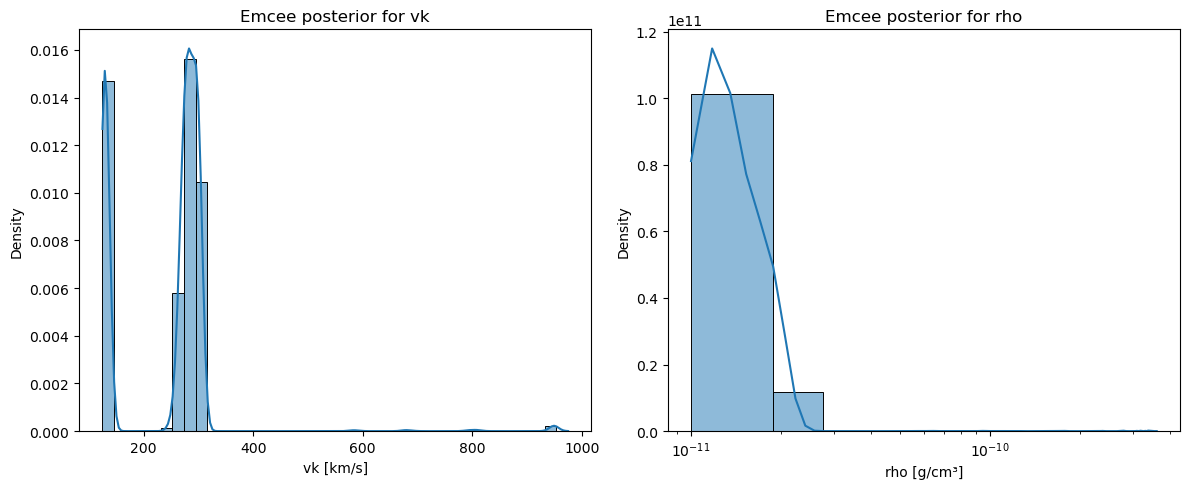

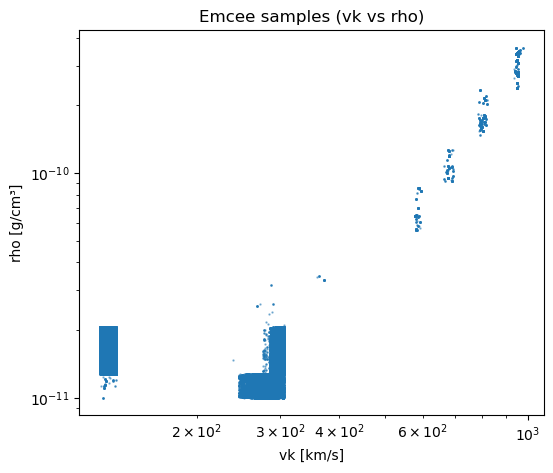


Best emcee model (nearest grid): vk=277.4, rho=1.309e-11


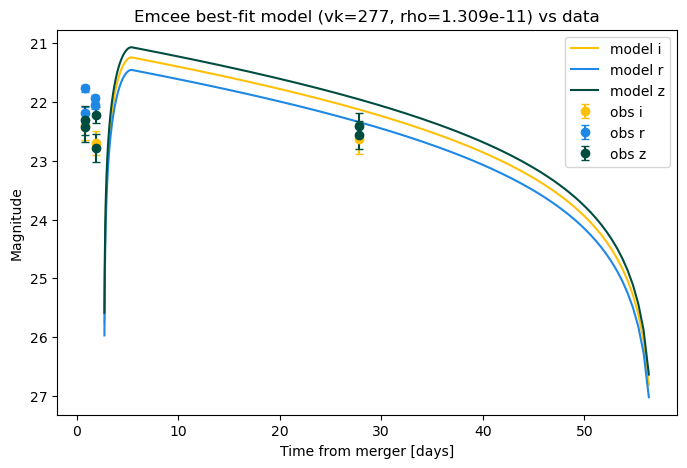

Done!


In [4]:
output_file = f"data/lc_dict_output_{list(events.keys())[0]}.pkl"

# lightcurves 
if os.path.exists(output_file):
    with open(output_file, "rb") as f:
        lc_dict = pickle.load(f)
    print(f"Loaded lc_dict from {output_file}.")
else:
    lc_dict = {"vk": [], "rho": [], "lc_df": []}
    for vk in vk_array:
        for rho in rho_array:
            out = L.run(
                M_BBH=events["S250328ae"]["total_mass"],   
                kick_velocity=vk,   
                density=rho,         
                height=height,   
                theta=theta,            
                mass_SMBH=mSMBH,         
                compute_qso=True,
                plot=False
            )
            lc_dict["vk"].append(vk)
            lc_dict["rho"].append(rho)
            lc_dict["lc_df"].append(out)
    with open(output_file, "wb") as f:
        pickle.dump(lc_dict, f)
    print(f"Saved lc_dict to {output_file}.")

candidates = pd.read_csv(f"data/{list(events.keys())[0]}_cand_test.csv")
candidates['time_from_merger'] = (Time(candidates['mjd'], format='mjd') - Time(events[list(events.keys())[0]]["start"], format='iso')).to_value('day') 

TIME_EQ_TOL = 0.2

#lc data
vk_arr = np.array(lc_dict["vk"])
rho_arr = np.array(lc_dict["rho"])
lc_dfs = lc_dict["lc_df"]

# data for candidate 
obs_times = candidates["time_from_merger"].values
obs_bands = candidates["band"].astype(str).values
obs_mags = candidates["mags"].values
obs_errs = np.maximum(candidates["magerrs"].values, 1e-3)  

unique_bands = np.unique(obs_bands)
band_to_col = {b: f"mag_qso_{b}" for b in unique_bands}


def log_posterior_fast(theta):
    vk, log10_rho = theta
    
    if not (100 <= vk <= 1000 and -11 <= log10_rho <= -7):
        return -np.inf
    
    # nearestneighbor 
    dist_vk = ((vk_arr - vk) / 900)**2 
    dist_rho = ((np.log10(rho_arr) - log10_rho) / 4)**2
    j = np.argmin(dist_vk + dist_rho)
    
    model_df = lc_dfs[j]
    chi2_sum = 0.0
    matched = 0
    
    for i in range(len(obs_times)):
        obs_time = obs_times[i]
        obs_band = obs_bands[i]
        obs_mag = obs_mags[i]
        obs_err = obs_errs[i]
        
        mag_key = band_to_col.get(obs_band)
        if mag_key is None or mag_key not in model_df.columns:
            continue
            
        time_array = model_df["time"].values
        match_idx = np.where(np.isclose(time_array, obs_time, atol=TIME_EQ_TOL))[0]
        if len(match_idx) == 0:
            continue
            
        model_mag = float(model_df.iloc[match_idx[0]][mag_key])
        chi2_sum += ((obs_mag - model_mag) / obs_err) ** 2
        matched += 1
    
    return -0.5 * chi2_sum if matched > 0 else -np.inf

def log_prob(theta):
    lp = log_posterior_fast(theta)
    return lp if np.isfinite(lp) else -np.inf


#Smaller  sampler settings
ndim = 2
nwalkers = 32      
nsteps = 10000    
walkers_burn = 2000

# initials
center_vk = np.median(vk_arr)
center_logrho = np.median(np.log10(rho_arr))
pos0 = np.zeros((nwalkers, ndim))
pos0[:, 0] = center_vk + 50 * np.random.randn(nwalkers)  # vk
pos0[:, 1] = center_logrho + 0.3 * np.random.randn(nwalkers)  # log10(rho)

pos0[:, 0] = np.clip(pos0[:, 0], 100, 1000)
pos0[:, 1] = np.clip(pos0[:, 1], -11, -7)

print("Running emcee...")
print(f"Initial vk range: {pos0[:,0].min():.1f} - {pos0[:,0].max():.1f}")
print(f"Initial log10(rho) range: {pos0[:,1].min():.2f} - {pos0[:,1].max():.2f}")

print("Testing initial positions...")
test_lp = np.array([log_prob(p) for p in pos0[:5]])
print(f"First 5 log probs: {test_lp}")
if np.any(~np.isfinite(test_lp)):
    print("WARNING: Some initial positions have -inf log prob")

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_prob,
    moves=emcee.moves.StretchMove()
)

sampler.run_mcmc(pos0, nsteps, progress=True)

samples = sampler.get_chain(discard=walkers_burn, flat=True)
vk_samples = samples[:, 0]
rho_samples = 10**samples[:, 1]  

vk_mean = np.mean(vk_samples)
rho_mean = np.mean(rho_samples)
vk_90 = np.quantile(vk_samples, [0.05, 0.95])
rho_90 = np.quantile(rho_samples, [0.05, 0.95])

print("\nEmcee posterior summaries:")
print(f"vk: mean={vk_mean:.2f}, 90% CI=[{vk_90[0]:.1f}, {vk_90[1]:.1f}]")
print(f"rho: mean={rho_mean:.3e}, 90% CI=[{rho_90[0]:.3e}, {rho_90[1]:.3e}]")

#  plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(vk_samples, kde=True, stat="density", bins=40)
plt.xlabel("vk [km/s]")
plt.title("Emcee posterior for vk")

plt.subplot(1, 2, 2)
sns.histplot(rho_samples, kde=True, stat="density", bins=40)
plt.xlabel("rho [g/cm³]")
plt.xscale("log")
plt.title("Emcee posterior for rho")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(vk_samples, rho_samples, s=0.5, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('vk [km/s]')
plt.ylabel('rho [g/cm³]')
plt.title('Emcee samples (vk vs rho)')
plt.show()

vk_best = np.median(vk_samples)
rho_best = np.median(rho_samples)

j_best = np.argmin(
    ((vk_arr - vk_best)/900)**2 + 
    ((np.log10(rho_arr) - np.log10(rho_best))/4)**2
)
best_model_df = lc_dfs[j_best]

print(f"\nBest emcee model (nearest grid): vk={vk_best:.1f}, rho={rho_best:.3e}")

plt.figure(figsize=(8, 5))
colors = {'g': '#D81B60', 'r': '#1E88E5', 'i': '#FFC107', 'z': '#004D40'}

for b, group in candidates.groupby("band"):
    mag_key = f"mag_qso_{b}"
    if mag_key not in best_model_df.columns:
        continue
    
    plt.errorbar(
        group["time_from_merger"],
        group["mags"],
        yerr=group["magerrs"],
        fmt="o",
        label=f"obs {b}",
        capsize=3,
        color=colors[b]
    )
    
    plt.plot(
        best_model_df["time"].values,
        best_model_df[mag_key].values,
        label=f"model {b}",
        color=colors[b]
    )
plt.gca().invert_yaxis()
plt.xlabel("Time from merger [days]")
plt.ylabel("Magnitude")
plt.title(f"Emcee best-fit model (vk={vk_best:.0f}, rho={rho_best:.3e}) vs data")
plt.legend()
plt.show()

out = {
    "emcee_sampler": sampler,
    "vk_samples": vk_samples,
    "rho_samples": rho_samples,
}
print("Done!")
